## Data Loading + Libraries Import

In [2]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  LabelEncoder, StandardScaler
from pathlib import Path

path = "../power_nap_vs_coffee_effectiveness_dataset.csv"
df = pd.read_csv(path) #df = nome standardizzato per DataFrame

df.shape, df.head(), df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   participant_id                 500 non-null    int64  
 1   age                            500 non-null    int64  
 2   occupation                     500 non-null    str    
 3   sleep_hours_previous_night     500 non-null    float64
 4   intervention_type              500 non-null    str    
 5   intervention_duration_minutes  500 non-null    int64  
 6   alertness_score_before         500 non-null    int64  
 7   alertness_score_after          500 non-null    int64  
 8   productivity_rating            500 non-null    int64  
 9   mood_rating                    500 non-null    int64  
 10  side_effects                   293 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 43.1 KB


((500, 11),
    participant_id  age            occupation  sleep_hours_previous_night  \
 0               1   24  Working Professional                         5.4   
 1               2   37               Student                         5.6   
 2               3   32  Working Professional                         4.4   
 3               4   28               Student                         6.9   
 4               5   25  Working Professional                         4.7   
 
   intervention_type  intervention_duration_minutes  alertness_score_before  \
 0         Power Nap                             15                      62   
 1         Power Nap                             30                      67   
 2            Coffee                             30                      44   
 3            Coffee                             30                      59   
 4         Power Nap                             30                      40   
 
    alertness_score_after  productivity_rating  

La prima cosa che notiamo, è che ci sono 293 non-missing values su 500 nella colonna Side Effects. Per fare una prova per l'esame, intepretiamo questi valori come "nessun side effect" e quindi non sono valori mancanti ma informativi. Se fosse un dataset vero, sarebbe da chiedere a chi ha creato il dataset e chiedere conferma se sia effettivamente così.

## Data Preprocessing

In [4]:
# Missing
(df.isna().mean().sort_values(ascending=False) * 100).round(1)

# Duplicati (participant_id dovrebbe essere unico)
df.duplicated().sum(), df["participant_id"].duplicated().sum()

# Valori strani / range rapidi
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
age,500.0,NaN,NaN,NaN,30.928,8.147612,18.0,24.0,31.0,38.0,44.0
occupation,500,3,Student,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours_previous_night,500.0,NaN,NaN,NaN,6.0586,1.136842,4.0,5.1,6.1,7.0,8.0
intervention_type,500,2,Coffee,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intervention_duration_minutes,500.0,NaN,NaN,NaN,22.3,5.654551,15.0,15.0,20.0,25.0,30.0
alertness_score_before,500.0,NaN,NaN,NaN,57.38,9.943306,40.0,49.0,58.0,65.0,74.0
alertness_score_after,500.0,NaN,NaN,NaN,71.23,11.420067,46.0,62.0,72.0,79.25,97.0
productivity_rating,500.0,NaN,NaN,NaN,5.374,2.842232,1.0,3.0,5.0,8.0,10.0
mood_rating,500.0,NaN,NaN,NaN,5.422,2.908752,1.0,3.0,5.0,8.0,10.0


Abbiamo deciso di utilizzare la funzione describe per ottenere informazioni su tutte le righe del dataframe. Poiché il dataset contiene sia variabili categoriali sia numeriche, è normale aspettarsi la presenza di diversi valori NaN in alcune metriche.

In particolare, i NaN attesi sono:
- Variabili numeriche → NaN in: unique, top, freq (metriche proprie delle variabili categoriali)
- Variabili categoriali → NaN in: mean, std, min e nei percentili (metriche proprie delle variabili numeriche)


## Pulizia dati

In questa fase abbiamo deciso di:
- togliere i duplicati. Nel caso di questo dataset, non è necessario, in quanto non sono presenti duplicati, ma è buona pratica fare comunque questo tipo di operazione
- sostituire i NaN con la stringa "None", dato che abbiamo deciso di interpretarli come "assenza di effetti collaterali"
- abbiamo deciso di convertire le variabili string "Intervention type", "Side effects" e "Occupation" al datatype "category", così da renderle più facilmente analizzabili

In [2]:
df = df.drop_duplicates(subset=["participant_id"]).copy()
df["side_effects"] = df["side_effects"].fillna("None")

# Categorie
df["intervention_type"] = df["intervention_type"].astype("category")
df["occupation"] = df["occupation"].astype("category")
df["side_effects"] = df["side_effects"].astype("category")
#df["intervention_duration_minutes"] = df["intervention_duration_minutes"].astype("category")
#l'ho commentata perchè chat ha suggerito di scalare se si vuole fare analisi numeriche o ML, trattala come numerica, ma se vuoi fare grafici categoriali o confronti tra gruppi, trattala come categoriale (magari ordinali). ci sta tenerla come varibile numerale per il random forest. questa cosa poi la spiego dopo meglio

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    int64   
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    int64   
 6   alertness_score_before         500 non-null    int64   
 7   alertness_score_after          500 non-null    int64   
 8   productivity_rating            500 non-null    int64   
 9   mood_rating                    500 non-null    int64   
 10  side_effects                   500 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 32.9 KB


In questo modo, grazie alla funzione info, abbiamo conferma che non sono più presenti valori NaN nel dataset e che le variabili di tipo stringa sono state correttamente convertite in tipo category.

________________________________________________________________________________

## Exploratory Data Analysis

## Feature engeneering

Abbiamo deciso che potesse essere interessante inserire una nuova variabile, alertness_delta. Per ogni partecipante, questa variabile restituisce un valore float calcolato come differenza tra alertness_after e alertness_before. In questo modo, possiamo verificare facilmente l'efficacia dei vari tipi di intervento.

Infatti, se l'alertness delta è positivo, significa che l'intervento ha avuto un effetto positivo. Se invece l'allertness delta è negativo, significa che l'intervento ha avuto un effetto negativo.

In [4]:
#Calcolo alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]

#Controllo se l'intervento ha funzionato
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    int64   
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    int64   
 6   alertness_score_before         500 non-null    int64   
 7   alertness_score_after          500 non-null    int64   
 8   productivity_rating            500 non-null    int64   
 9   mood_rating                    500 non-null    int64   
 10  side_effects                   500 non-null    category
 11  alertness_delta                500 non-null    int64   
dtypes: category(3), float64(1), int64(8)
memory usa

## Architettura dataframe

Il processo di gestione dei dati è stato strutturato in diverse fasi, creando versioni differenti del dataframe a seconda dell’obiettivo analitico (EDA o ML). Questo approccio consente di mantenere separati i diversi step dell’analisi, evitando errori metodologici (come il data leakage).

I dataframe che abbiamo creato sono:
- **df**: dati puliti non scalati, utilizzati per analisi descrittive
- **df_clean_scaled**: dati scalati per analisi dati e identificazione outlier
- **df_encoded**: dataframe in qui viene fatto l'encoding delle variabili categoriali su dati puliti, senza fare scaling. Il motivo per cui non abbiamo fatto encoding su df_clean_scaled è che, in fase di modellazione, bisogna usare i dati non scalati, per evitare il leakage di informazioni del test set in fase di training.
- **df_encoded_corr**: dataframe con encoding + scaling, che usiamo solo al fine di fare l'analisi della  correlazione fra le varie features


df (raw)
↓
df (preprocessing)
↓
├─ EDA
│  ├─ df
│  └─ df_clean_scaled
│
└─ Modelling
   ├─ df_encoded
   │  └─ df_encoded_scaled
   └─ df_encoded_corr

## Scaling


In questo blocco creiamo una copia del dataset df contenente le variabili numeriche standardizzate, così da renderle confrontabili tra loro nonostante le differenze nei valori originali. La standardizzazione verrà inoltre utilizzata per la costruzione dei grafici, in modo da rendere più facilmente osservabili outliers, eventuali differenze nelle medie e nelle distribuzioni.

Per le analisi EDA, abbiamo deciso di non standardizzare la durata dell’intervento, poiché si tratta di variabili discrete che trattiamo come categoriali, in quanto rappresentano intervalli di tempo piuttosto che una durata temporale precisa.

In [7]:
scaler = StandardScaler()

# Standardizza le colonne specifiche
cols_to_scale = ["sleep_hours_previous_night", "alertness_delta", "productivity_rating", "mood_rating", "alertness_score_before", "alertness_score_after", "age"]
df_clean_scaled = df.copy()
df_clean_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df_clean_scaled.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    float64 
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    int64   
 6   alertness_score_before         500 non-null    float64 
 7   alertness_score_after          500 non-null    float64 
 8   productivity_rating            500 non-null    float64 
 9   mood_rating                    500 non-null    float64 
 10  side_effects                   500 non-null    category
 11  alertness_delta                500 non-null    float64 
dtypes: category(3), float64(7), int64(2)
memory usa

## Encoding

In questo blocco di codice facciamo encoding sulle colonne categoriali aderendo rigidamente alla Golden Rule:
1) La variabile Side_Effects riceve un semplice label encoding in quanto è scelta come variabile target, ed è quindi esclusa dalla feature matrix #todo: va spiegato come mai scegliamo questa variabile come indipendente
2) Le variabili Intervention_Type e Occupation ricevono un Dummy encoding in quanto sono categoriali e incluse nella feature matrix
3) La variabile "intervention_duration_minutes" ha subito un trattamento particolare. Nonostante sia presentata come variabile continua, in realtà è una variabile categoriale ordinale con 4 categorie di durata (15/20/25/30 min).

In [5]:
le = LabelEncoder()

df_encoded = df.copy()

#We apply simple label encoding to the "side_effects" since it's categorical and target
df_encoded["side_effects"] = le.fit_transform(df["side_effects"])

#We apply one-hot econding to the "intervention_type" and "occupation" since they are categorical and not target
df_encoded["intervention_type"] = le.fit_transform(df["intervention_type"])
df_encoded = pd.get_dummies(df_encoded, columns=["occupation"])
print(df_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    int64  
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    int64  
 5   alertness_score_before           500 non-null    int64  
 6   alertness_score_after            500 non-null    int64  
 7   productivity_rating              500 non-null    int64  
 8   mood_rating                      500 non-null    int64  
 9   side_effects                     500 non-null    int64  
 10  alertness_delta                  500 non-null    int64  
 11  occupation_Freelancer            500 non-null    bool   
 12  occupation_Student               

In [8]:
df_encoded_corr = df_encoded.copy()
df_encoded_corr[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

#NB: scaler e cols_to_scale sono quelli definiti in precedenza.
df_encoded_corr.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    float64
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    int64  
 5   alertness_score_before           500 non-null    float64
 6   alertness_score_after            500 non-null    float64
 7   productivity_rating              500 non-null    float64
 8   mood_rating                      500 non-null    float64
 9   side_effects                     500 non-null    int64  
 10  alertness_delta                  500 non-null    float64
 11  occupation_Freelancer            500 non-null    bool   
 12  occupation_Student               

________________________________________________________________________________

## Feature Correlation

In questa sezione vogliamo osservare se ci sono feature correlate fra di loro, in modo tale da eliminare eventuali collinearità. Creiamo quindi una matrice di correlazione, che poi decidiamo di rendere in maniera grafica con un clustermap.

In [10]:
df_encoded_corr = df_encoded_corr.drop('participant_id', axis=1, inplace=False)
corr_matrix = df_encoded_corr.corr()
corr_matrix

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,alertness_score_before,alertness_score_after,productivity_rating,mood_rating,side_effects,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
age,1.000000,0.030162,-0.000882,-0.000748,-0.041219,-0.012809,-0.016748,-0.003704,0.006059,0.052263,-0.033454,-0.008768,0.041856
sleep_hours_previous_night,0.030162,1.000000,0.038056,-0.054677,-0.005307,0.023071,-0.030861,0.038625,0.030667,0.062705,-0.034388,0.027450,0.005146
intervention_type,-0.000882,0.038056,1.000000,0.017932,0.037558,0.300425,0.009327,-0.034251,0.505889,0.606239,-0.028205,0.001485,0.026067
intervention_duration_minutes,-0.000748,-0.054677,0.017932,1.000000,0.026661,0.018481,-0.096026,-0.051210,-0.051868,-0.010717,-0.071758,0.045954,0.022505
alertness_score_before,-0.041219,-0.005307,0.037558,0.026661,1.000000,0.897609,0.001839,0.017587,-0.031097,0.060964,0.037145,-0.064793,0.030948
alertness_score_after,-0.012809,0.023071,0.300425,0.018481,0.897609,1.000000,0.000864,0.033631,0.100272,0.494693,0.057389,-0.085849,0.033006
productivity_rating,-0.016748,-0.030861,0.009327,-0.096026,0.001839,0.000864,1.000000,0.013838,0.023331,-0.001671,-0.098140,0.047801,0.046410
mood_rating,-0.003704,0.038625,-0.034251,-0.051210,0.017587,0.033631,0.013838,1.000000,0.051640,0.041482,0.010717,-0.020107,0.010397
side_effects,0.006059,0.030667,0.505889,-0.051868,-0.031097,0.100272,0.023331,0.051640,1.000000,0.288369,0.012828,-0.050409,0.039810
alertness_delta,0.052263,0.062705,0.606239,-0.010717,0.060964,0.494693,-0.001671,0.041482,0.288369,1.000000,0.056718,-0.066654,0.013721


<Figure size 1600x900 with 0 Axes>

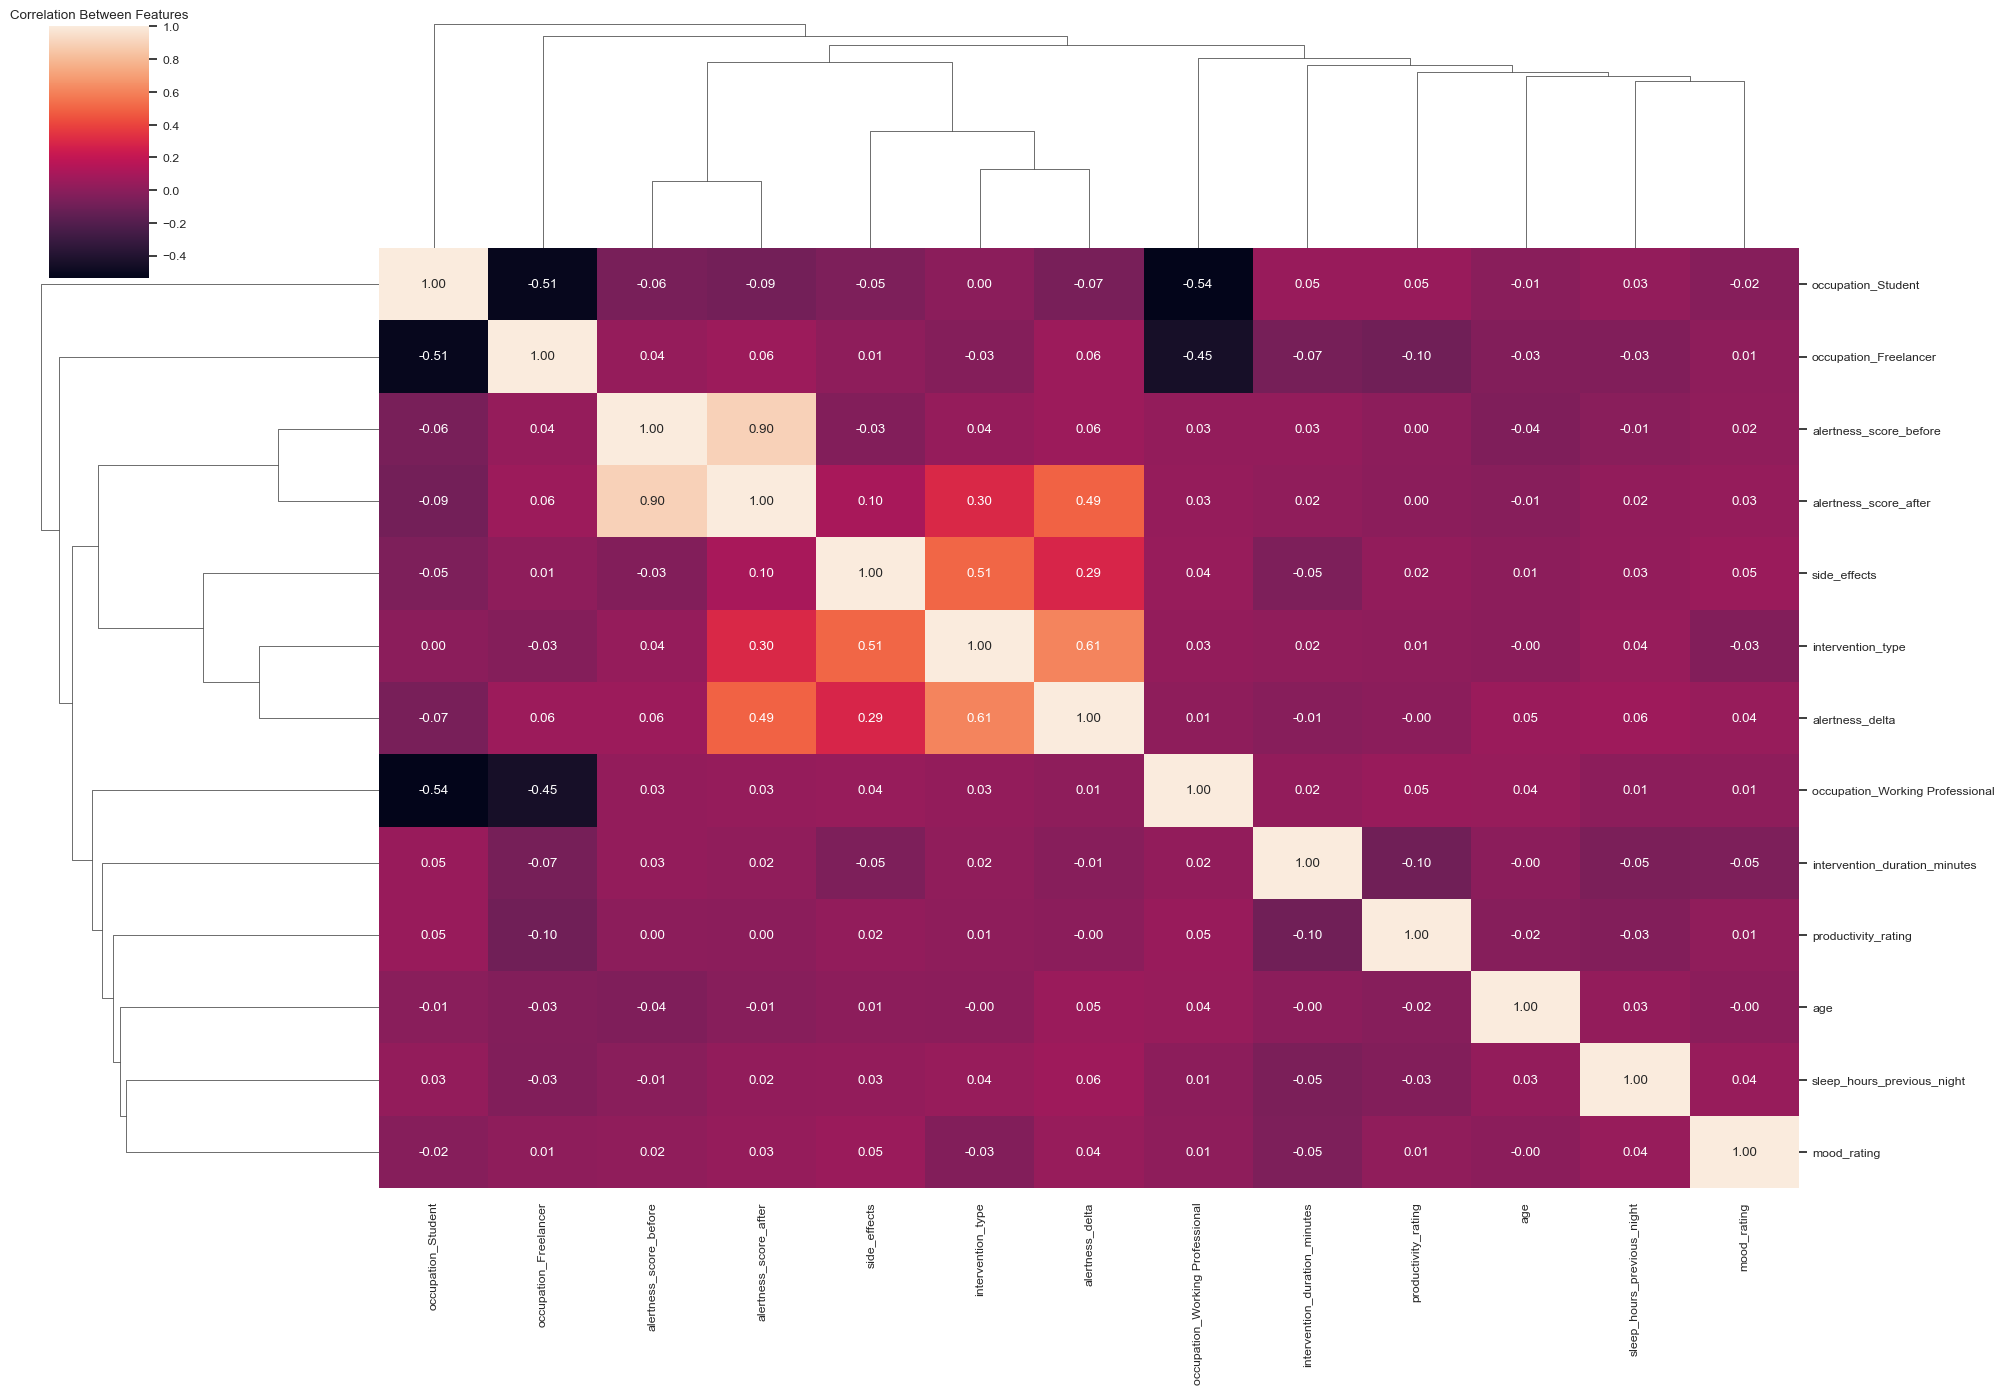

In [11]:
sns.set(font_scale=0.8)
plt.figure(figsize=(16,9))
sns.clustermap(corr_matrix,annot=True,fmt=".2f",figsize=(20,14)) # Plot the correlation matrix as a hierarchically-clustered heatmap.
plt.title("Correlation Between Features")
plt.show()

Osserviamo che le uniche features che hanno una correlazione significativa (>0.80 o < -0.80) sono l'alertness_score_before e l'alertness_score_after: per questo motivo, in seguito, verrà solamente considerata la variabile alertness_delta

_______________________________________________________________________

## OUTLIER DETECTION

Vogliamo individuare gli outlier nelle colonne numeriche del dataframe standardizzato (df_clean_scaled). Per questo motivo, abbiamo creato una funzione che calcoli in automatico interquartili e outlier per ogni colonna numerica, restituendo una maschera booleana. Successivamente, abbiamo visualizzato la distribuzione delle varibili numeriche con dei boxplot.

In [12]:
num_cols = df_clean_scaled.select_dtypes(include="number").columns.drop("participant_id", errors="ignore")

def iqr_outlier_mask(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (s < lower) | (s > upper)
#Ho fatto sta cosa per il discorso di Vandin dell'essere pythonici. Forse questo potrebbe essere messo in uno script a parte e chiamato importando lo script con tutti i metodi (ALICE PLS CHIEDI A VANDIN QUANDO VAI A LEZIONE <3)

#qui applico la mia nuova maschera a tutte le colonne numeriche e creo un DataFrame con i risultati
outlier_mask = pd.DataFrame({c: iqr_outlier_mask(df_clean_scaled[c]) for c in num_cols})

# riepilogo: quanti outlier per colonna
outlier_summary = (
    outlier_mask.sum()
    .to_frame("n_outliers")
    .assign(pct_outliers=lambda x: (x["n_outliers"] / len(df) * 100).round(2))
    .sort_values("n_outliers", ascending=False)
)

outlier_summary

,n_outliers,pct_outliers
age,0,0.0
sleep_hours_previous_night,0,0.0
alertness_score_before,0,0.0
alertness_score_after,0,0.0
productivity_rating,0,0.0
mood_rating,0,0.0
alertness_delta,0,0.0


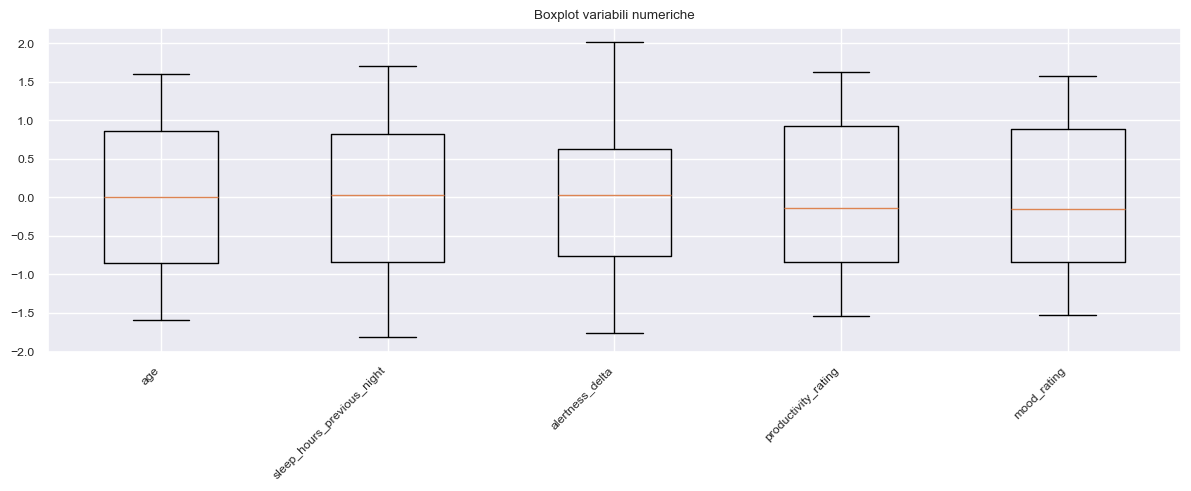

In [30]:
cols_to_boxplot = ["age", "sleep_hours_previous_night", "alertness_delta", "productivity_rating", "mood_rating"]

data = [df_clean_scaled[c].dropna().values for c in cols_to_boxplot]

plt.figure(figsize=(12, 5))
plt.boxplot(data, tick_labels=cols_to_boxplot, showfliers=True)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot variabili numeriche")
plt.tight_layout()
plt.show()

Osserviamo che non abbiamo ottenuto outliers.

_________________________________________________________________________________

## ANALISI ESPLORATIVE + GRAFICHETTI

**PARTE 0**: La distribuzione della variabile target

In questa fase vogliamo osservare la distribuzione dei side effects nella popolazione. Infatti, è importante vedere se la distribuzione della variabile target è più o meno bilanciata. Queste informazioni sono importanti per le fasi successive, in quanto saranno utili per addestrare il modello che predirrà la comparsa di effetti collaterali, in particolar modo servono per scegliere il tipo di errore che dovrà minimizzare il modello.

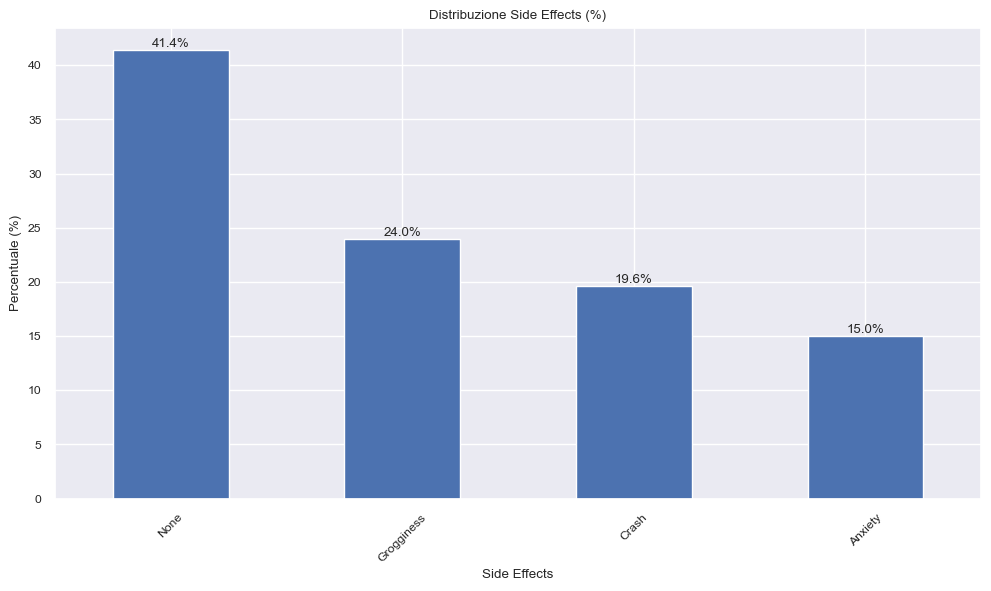

In [14]:
# Calcola le percentuali
side_effects_pct = df['side_effects'].value_counts(normalize=True) * 100

# Crea il barplot
ax = side_effects_pct.plot(kind='bar', figsize=(10, 6))
ax.set_ylabel('Percentuale (%)')
ax.set_xlabel('Side Effects')
ax.set_title('Distribuzione Side Effects (%)')
plt.xticks(rotation=45)

# Aggiungi valori sulle barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

Osserviamo che l'assenza di effetti collaterali è nettamente più presente nella popolazione rispetto agli altri effetti. Abbiamo deciso quindi di osservare la distribuzione del tipo di intervento e dei side effects.


C:\Users\Paolo\AppData\Local\Temp\ipykernel_14420\188199493.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y*100/total)}%' for y in y_ticks])


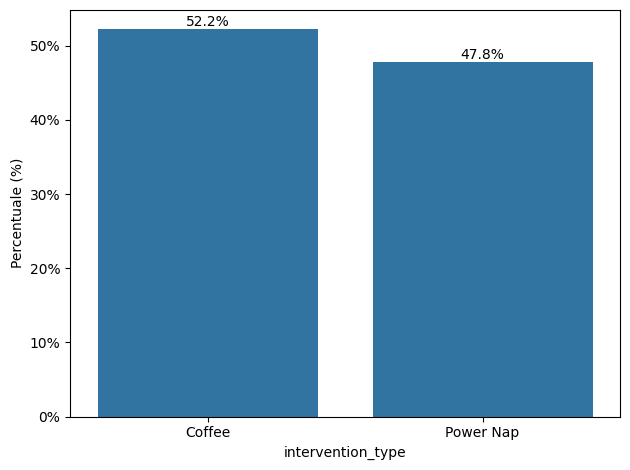

In [9]:
ax = sns.countplot(data=df, x="intervention_type")

# Calcola il totale per le percentuali
total = len(df)

# Modifica l'asse Y per mostrare percentuali
y_ticks = ax.get_yticks()
ax.set_yticklabels([f'{int(y*100/total)}%' for y in y_ticks])
ax.set_ylabel('Percentuale (%)')

# Aggiungi le percentuali sopra le barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{100*height/total:.1f}%',
                xy=(p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

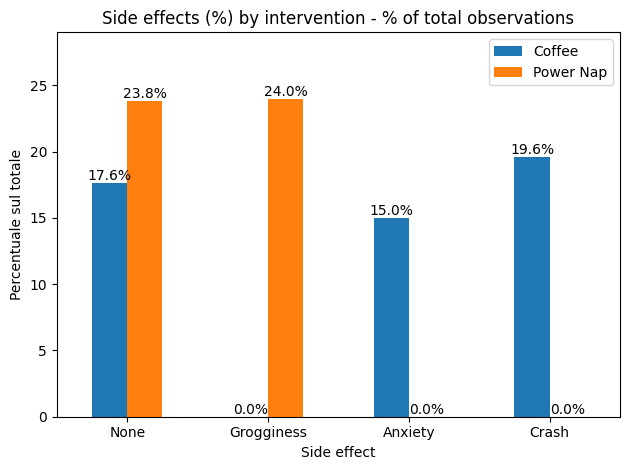

In [10]:
total = len(df)  # Totale generale
side_effects = ["None", "Grogginess", "Anxiety", "Crash"]

# Calcola i conteggi per Coffee
coffee_counts = (
    df[df["intervention_type"] == "Coffee"]["side_effects"]
    .value_counts()
    .reindex(side_effects, fill_value=0)
)

# Calcola i conteggi per Power Nap
nap_counts = (
    df[df["intervention_type"] == "Power Nap"]["side_effects"]
    .value_counts()
    .reindex(side_effects, fill_value=0)
)

# Converti in percentuali sul TOTALE GENERALE (non sul totale del gruppo)
coffee_pct = (coffee_counts / total) * 100
nap_pct = (nap_counts / total) * 100

# Dataframe unico
plot_df = pd.DataFrame({
    "Coffee": coffee_pct,
    "Power Nap": nap_pct
})

ax = plot_df.plot(kind="bar")

plt.title("Side effects (%) by intervention - % of total observations")
plt.xlabel("Side effect")
plt.ylabel("Percentuale sul totale")
plt.ylim(0, plot_df.max().max() + 5)  # Un po' di spazio in più
plt.xticks(rotation=0)

# Etichette percentuali
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%",
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

**PARTE 1**: Intervention type x Alertness

Sto utilizzando ALERTNESS DELTA come prima variabile dipendente, usando il tipo di intervento come indipendente. 

Questo sulla base dei seguenti assunti:

 1 - che ci interessi verificare, come prima cosa quale tipo di intervento sia più "riposante"

 2 - che la nuova colonnina "alertness_delta" sia un adeguato indicatore di quanto "riposante" sia stato l'intervento

In [11]:
#descrittive per alertness_delta raggruppato per intervento
df.groupby("intervention_type")["alertness_delta"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
intervention_type,,,,,,,,
Coffee,261.0,10.93,3.86,5.0,7.0,11.0,15.0,17.0
Power Nap,239.0,17.04,4.18,10.0,14.0,17.0,21.0,24.0


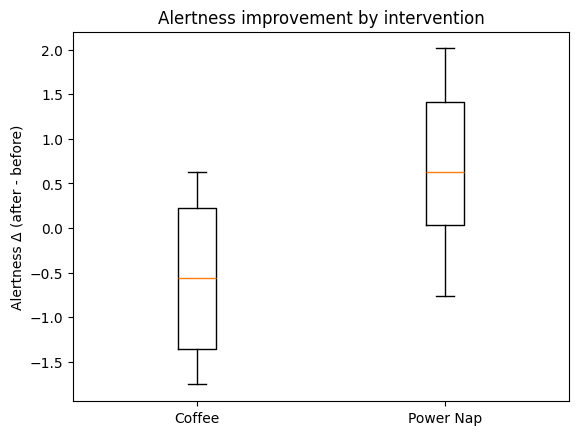

In [12]:
#Creo i miei dati d'interesse per il boxplot
data = [
    df_clean_scaled.loc[df_encoded["intervention_type"]==0, "alertness_delta"],
    df_clean_scaled.loc[df_encoded["intervention_type"]==1, "alertness_delta"]
]

#Disegno il Boxplot (non ho idea di cosa sia metà di queste cose, grazie ChatGPT)
plt.boxplot(data, tick_labels=["Coffee","Power Nap"])
plt.ylabel("Alertness Δ (after - before)")
plt.title("Alertness improvement by intervention")
plt.show()

Sembra dal boxplot che il power nap migliori, mentre il caffè peggiori l'alertness. Questo è abbastanza sorprendente, almeno per il senso comune.

**PARTE 2**: Intervention Type x Intervention duration

Sto utilizzando Intervention duration (che ha solo 15/20/25/30) come seconda variabile dipendente, usando il tipo di intervento come indipendente. 

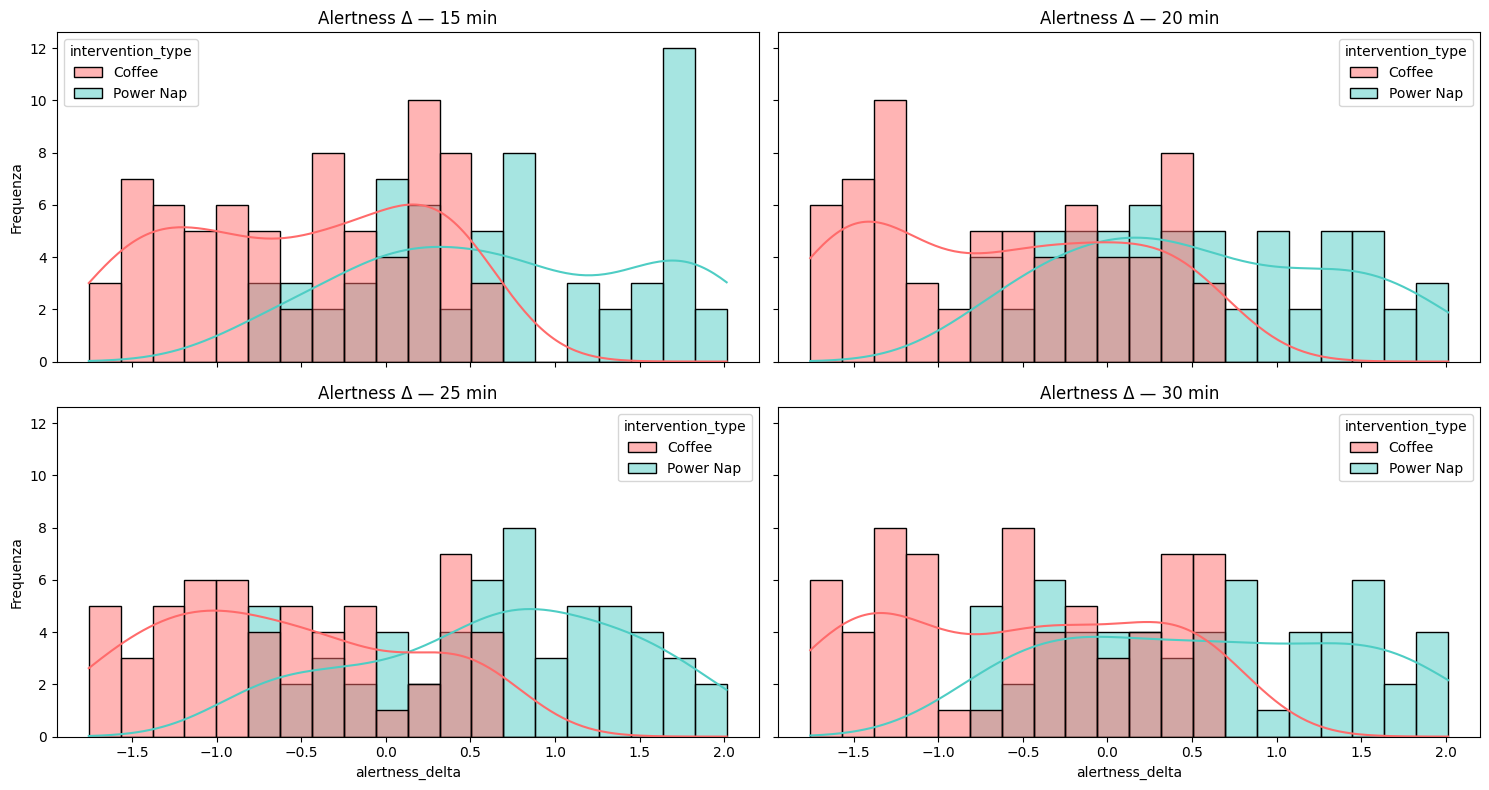

In [13]:
df_t15 = df_clean_scaled[df_clean_scaled["intervention_duration_minutes"] == 15]["alertness_delta"]
df_t20 = df_clean_scaled[df_clean_scaled["intervention_duration_minutes"] == 20]["alertness_delta"]
df_t25 = df_clean_scaled[df_clean_scaled["intervention_duration_minutes"] == 25]["alertness_delta"]
df_t30 = df_clean_scaled[df_clean_scaled["intervention_duration_minutes"] == 30]["alertness_delta"]

datasets = {
    "15 min": df_t15,
    "20 min": df_t20,
    "25 min": df_t25,
    "30 min": df_t30,
}

durations = sorted(df_clean_scaled["intervention_duration_minutes"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, duration in zip(axes, durations):
    data_duration = df_clean_scaled[df_clean_scaled["intervention_duration_minutes"] == duration]

    if len(data_duration) > 0:  # Verifica che ci siano dati
        sns.histplot(
            data=data_duration,
            x="alertness_delta",
            hue="intervention_type",
            bins=20,
            kde=True,
            stat="count",
            ax=ax,
            palette=["#FF6B6B", "#4ECDC4"]
        )
        ax.set_title(f"Alertness Δ — {duration} min")
        ax.set_xlabel("alertness_delta")
        ax.set_ylabel("Frequenza")
    else:
        ax.text(0.5, 0.5, f"No data for {duration} min", ha="center", va="center")
        ax.set_title(f"Alertness Δ — {duration} min")

plt.tight_layout()
plt.show()

Osservando la distribuzione dei grafici, abbiamo scoperto che la distribuzione dell'alertness delta, alertness_before, alertness delta % e alertness delta standardizzata non sono neanche lontanamente normali...
per questo decidiamo di studiare la mediana + fare i boxplot
 

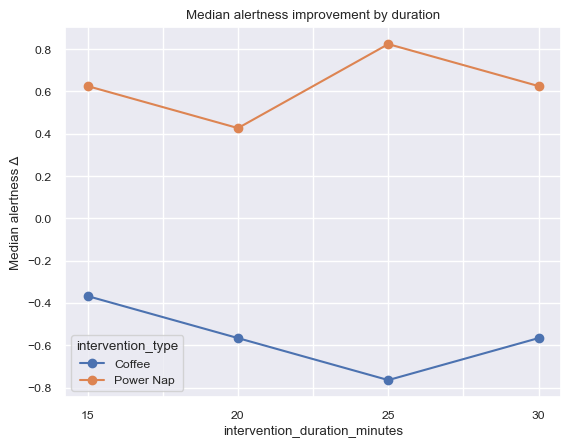

In [20]:
pivot = df_clean_scaled.pivot_table(
    index="intervention_duration_minutes",
    columns="intervention_type",
    values="alertness_delta",
    aggfunc="median"
).sort_index()

pivot.plot(marker="o")
plt.ylabel("Median alertness Δ")
plt.title("Median alertness improvement by duration")
plt.show()

Sembra che ci sia una CHIARISSIMA differenza nei livelli di alertness fra caffe e power nap. Questo si vedeva anche dal boxplot, ma da qui si può vedere che per la duration time di 25 minuti ci sia la maggiore differenza di Delta-awareness (pari a 1.6).

Intanto facciamo i boxplot per delta allertness e intervention duration, dato che funzionano meglio per le distribuzioni non normali. Prima facciamo solo l'alertness improvement vs duration time, e si vede che il delta non cambia. Questo conferma l'importanza di studiare l'intersezione fra metodo vs duration

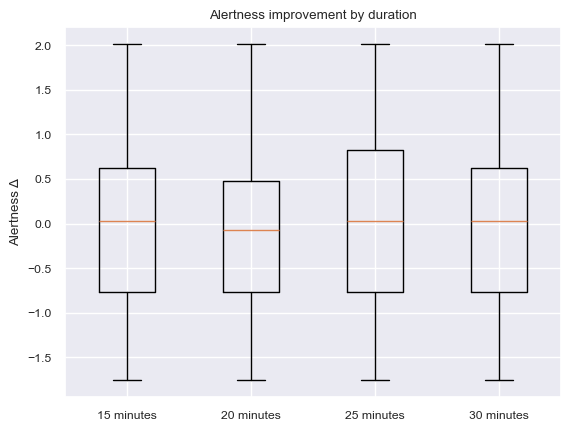

In [21]:
durations = [15, 20, 25, 30]
df_duration = [df_clean_scaled[(df_clean_scaled["intervention_duration_minutes"]==d)]["alertness_delta"]
    for d in durations]

#Disegno il Boxplot (non ho idea di cosa sia metà di queste cose, grazie ChatGPT)
plt.boxplot(df_duration, tick_labels=["15 minutes","20 minutes", "25 minutes", "30 minutes"])
plt.ylabel("Alertness Δ")
plt.title("Alertness improvement by duration")
plt.show()

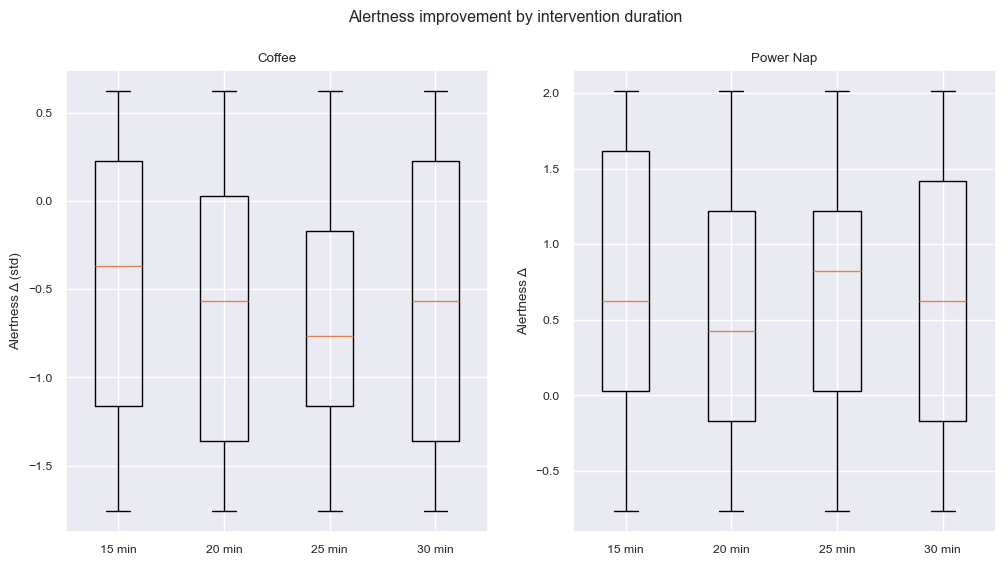

In [22]:
durations = [15, 20, 25, 30]

# Coffee
coffee_data = [
    df_clean_scaled[(df_clean_scaled["intervention_type"]=="Coffee") & (df_clean_scaled["intervention_duration_minutes"]==d)]["alertness_delta"]
    for d in durations
]

# Power Nap
nap_data = [
    df_clean_scaled[(df_clean_scaled["intervention_type"]=="Power Nap") & (df_clean_scaled["intervention_duration_minutes"]==d)]["alertness_delta"]
    for d in durations
]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot Coffee
axes[0].boxplot(coffee_data, tick_labels=[f"{d} min" for d in durations])
axes[0].set_title("Coffee")
axes[0].set_ylabel("Alertness Δ (std)")

# Boxplot Power Nap
axes[1].boxplot(nap_data, tick_labels=[f"{d} min" for d in durations])
axes[1].set_title("Power Nap")
axes[1].set_ylabel("Alertness Δ")

plt.suptitle("Alertness improvement by intervention duration")
plt.show()

Alice: comunque si vede che questo dataset non è di italiani, chi cazzo si beve un caffè in mezz'ora? Comunque possiamo concludere che, considerando la mediana, i power nap di 25 minuti sono più efficaci. 

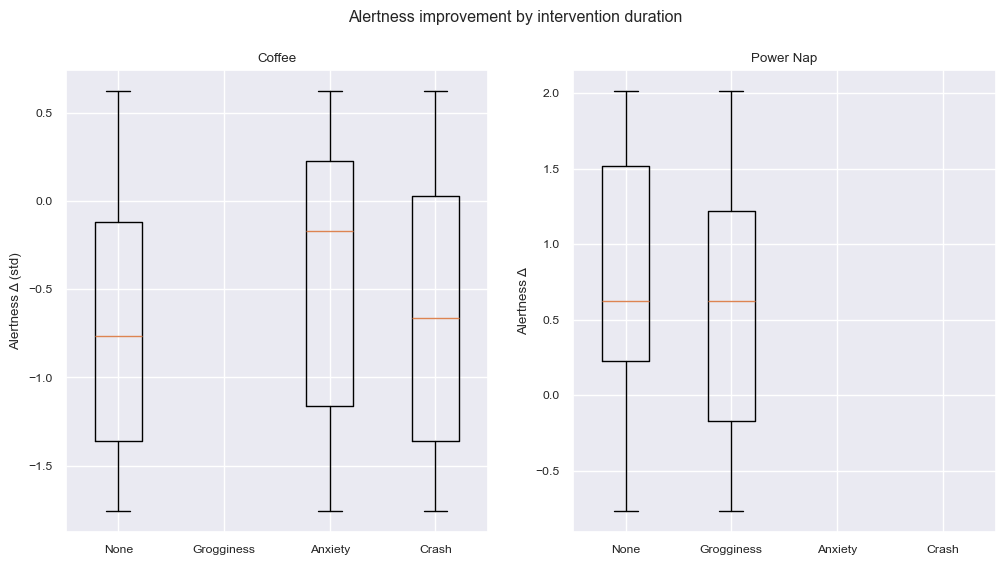

In [23]:
side_effects_list = ["None", "Grogginess", "Anxiety", "Crash"]

# Coffee
coffee_data = [
    df_clean_scaled[(df_clean_scaled["intervention_type"]=="Coffee") & (df_clean_scaled["side_effects"]==d)]["alertness_delta"]
    for d in side_effects_list
]

# Power Nap
nap_data = [
    df_clean_scaled[(df_clean_scaled["intervention_type"]=="Power Nap") & (df_clean_scaled["side_effects"]==d)]["alertness_delta"]
    for d in side_effects_list
]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot Coffee
axes[0].boxplot(coffee_data, tick_labels=[f"{d}" for d in side_effects_list])
axes[0].set_title("Coffee")
axes[0].set_ylabel("Alertness Δ (std)")

# Boxplot Power Nap
axes[1].boxplot(nap_data, tick_labels=[f"{d}" for d in side_effects_list])
axes[1].set_title("Power Nap")
axes[1].set_ylabel("Alertness Δ")

plt.suptitle("Alertness improvement by intervention duration")
plt.show()

**PARTE 3**: Intervention Type X side effects

Vediamo quindi che i power nap danno meno side effects rispetto al caffè, e che i tipi di sintomi dipendono dal tipo di intervento

## NEW CSV PRODUCTION

In [24]:
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    int64   
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    category
 6   alertness_score_before         500 non-null    int64   
 7   alertness_score_after          500 non-null    int64   
 8   productivity_rating            500 non-null    int64   
 9   mood_rating                    500 non-null    int64   
 10  side_effects                   500 non-null    category
 11  alertness_delta                500 non-null    int64   
dtypes: category(4), float64(1), int64(7)
memory usa

((500, 12), None)

In [25]:
df_clean_scaled.shape, df_clean_scaled.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    float64 
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    category
 6   alertness_score_before         500 non-null    float64 
 7   alertness_score_after          500 non-null    float64 
 8   productivity_rating            500 non-null    float64 
 9   mood_rating                    500 non-null    float64 
 10  side_effects                   500 non-null    category
 11  alertness_delta                500 non-null    float64 
dtypes: category(4), float64(7), int64(1)
memory usa

((500, 12), None)

In [26]:
df_encoded.shape, df_encoded.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   participant_id                   500 non-null    int64   
 1   age                              500 non-null    int64   
 2   sleep_hours_previous_night       500 non-null    float64 
 3   intervention_type                500 non-null    int64   
 4   intervention_duration_minutes    500 non-null    category
 5   alertness_score_before           500 non-null    int64   
 6   alertness_score_after            500 non-null    int64   
 7   productivity_rating              500 non-null    int64   
 8   mood_rating                      500 non-null    int64   
 9   side_effects                     500 non-null    int64   
 10  alertness_delta                  500 non-null    int64   
 11  occupation_Freelancer            500 non-null    bool    
 12  occupation_Student 

((500, 14), None)

In [27]:
df_encoded_corr.shape, df_encoded_corr.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   age                              500 non-null    float64 
 1   sleep_hours_previous_night       500 non-null    float64 
 2   intervention_type                500 non-null    int64   
 3   intervention_duration_minutes    500 non-null    category
 4   alertness_score_before           500 non-null    float64 
 5   alertness_score_after            500 non-null    float64 
 6   productivity_rating              500 non-null    float64 
 7   mood_rating                      500 non-null    float64 
 8   side_effects                     500 non-null    int64   
 9   alertness_delta                  500 non-null    float64 
 10  occupation_Freelancer            500 non-null    bool    
 11  occupation_Student               500 non-null    bool    
 12  occupation_Working 

((500, 13), None)

Il seguente blocco pulisce DF_Encoded per prepare il salvataggio di un file .csv preparatorio per la parte di ML

In [28]:
df_encoded = df_encoded.drop(["alertness_score_before", "alertness_score_after"], axis=1)
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   participant_id                   500 non-null    int64   
 1   age                              500 non-null    int64   
 2   sleep_hours_previous_night       500 non-null    float64 
 3   intervention_type                500 non-null    int64   
 4   intervention_duration_minutes    500 non-null    category
 5   productivity_rating              500 non-null    int64   
 6   mood_rating                      500 non-null    int64   
 7   side_effects                     500 non-null    int64   
 8   alertness_delta                  500 non-null    int64   
 9   occupation_Freelancer            500 non-null    bool    
 10  occupation_Student               500 non-null    bool    
 11  occupation_Working Professional  500 non-null    bool    
dtypes: bool(3), categor

In [29]:
from pathlib import Path

csv_path = Path("df_encoded.csv")

if csv_path.exists():
    overwrite = input(f"Il file {csv_path} esiste già. Sovrascrivere? (s/n): ")
    if overwrite.lower() != 's':
        print("Operazione annullata.")
    else:
        df_encoded.to_csv(csv_path, index=False)
        print(f"✓ File sovrascritto: {csv_path}")
else:
    df_encoded.to_csv(csv_path, index=False)
    print(f"✓ File salvato: {csv_path}")

Operazione annullata.
